In [1]:
import pickle
import torch
import torch.nn.functional as F

path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_temp1_topp1_dp_100/results'
sample = 'result_00157461.pkl'

with open(f'{path}/{sample}', 'rb') as f:
    r = pickle.load(f)

# def get_predictive_entropy(log_likelihoods):
#     """Compute predictive entropy of approximate posterior predictive"""
#     mean_across_models = torch.logsumexp(log_likelihoods, dim=0) - torch.log(torch.tensor(log_likelihoods.shape[0]))
#     entropy = -torch.sum(mean_across_models, dim=1) / torch.tensor(mean_across_models.shape[1])
#     return entropy

# # Assuming you have 20 responses with scores and corresponding token IDs
# scores_of_20_resp = r['scores']  # List of tensors, each tensor has shape (seq_len, num_beams, vocab_size)
# tokens_of_20_responses = r['tokens']  # List of tensors, each tensor has shape (seq_len, num_beams)

# log_likelihoods = []

# for score, token_ids in zip(scores_of_20_resp, tokens_of_20_responses):
#     # Step 1: Compute log softmax of scores
#     log_probs = F.log_softmax(score, dim=-1)  # Log probabilities over the vocabulary

#     # Step 2: Gather log probabilities corresponding to the generated tokens
#     log_probs_generated_tokens = log_probs[torch.arange(log_probs.size(0)), torch.arange(log_probs.size(1)), token_ids]

#     # Step 3: Compute the average log likelihood for the sequence
#     avg_log_likelihood = log_probs_generated_tokens.mean(dim=-1).squeeze()

#     # Step 4: Append the average log likelihood for this sequence to the list
#     log_likelihoods.append(avg_log_likelihood)

In [2]:
import torch
import torch.nn.functional as F

def compute_predictive_entropy(raw_logits, token_ids):
    """
    Compute predictive entropy given raw logits and sequence of token IDs.

    Args:
        raw_logits (list of tensors): List of N tensors, each with shape (1, num_tokens, vocab_size)
        token_ids (list of tensors): List of N tensors, each with shape (num_tokens,)

    Returns:
        entropy (tensor): Predictive entropy, shape (N,)
    """
    # Convert raw logits to log probabilities
    log_probs = []
    for logits in raw_logits:
        log_probs.append(F.log_softmax(logits, dim=-1))

    # Extract log probabilities of observed tokens
    observed_log_probs = []
    for log_prob, token_id in zip(log_probs, token_ids):
        observed_log_prob = log_prob[0, torch.arange(log_prob.shape[1]), token_id]
        observed_log_probs.append(torch.mean(observed_log_prob, dim=1))
        
    print(torch.stack(observed_log_probs).shape)

    # Compute predictive entropy
    entropy = -torch.stack(observed_log_probs).mean(dim=0).squeeze()

    return entropy

In [3]:
raw_logits = r['scores']
token_ids = r['tokens']

print(compute_predictive_entropy(raw_logits, token_ids))

torch.Size([20, 1])
tensor(0.6034)


In [4]:
# # Step 5: Stack all log likelihoods for the sequences to prepare for entropy calculation
# log_likelihoods = torch.stack(log_likelihoods)

# # Step 6: Calculate the predictive entropy using the provided function
# predictive_entropy = get_predictive_entropy(log_likelihoods)

# print("Predictive Entropy of the sequences:", predictive_entropy)

In [2]:
path = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_temp1_topp1_dp_100/results'
sample = 'result_00157461.pkl'

In [3]:
import json
with open("/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_0.json") as file:
    questions = json.load(file)

In [4]:
questions['00157461']

{'semantic': [{'operation': 'select',
   'dependencies': [],
   'argument': 'table (1010128)'},
  {'operation': 'exist', 'dependencies': [0], 'argument': '?'}],
 'entailed': [],
 'equivalent': ['00157461'],
 'question': 'Is there a table in the photo?',
 'imageId': '2318494',
 'isBalanced': False,
 'groups': {'global': None, 'local': '03-table'},
 'answer': 'yes',
 'semanticStr': 'select: table (1010128)->exist: ? [0]',
 'annotations': {'answer': {},
  'question': {'3': '1010128'},
  'fullAnswer': {'4': '1010128'}},
 'types': {'detailed': 'exist', 'semantic': 'obj', 'structural': 'verify'},
 'fullAnswer': 'Yes, there is a table.'}

In [5]:
import pickle

with open(f'{path}/{sample}', 'rb') as f:
    r = pickle.load(f)

In [6]:
r.keys()

dict_keys(['responses', 'answer', 'full_answer', 'sequence_probabilities', 'scores', 'tokens'])

In [10]:
for i in list(r.keys()):
    print(i)
    print(len(r[i]))
    
# responses
# 20
# answer -> 'Yes' -> not a list, hence length is not 20
# 3 
# full_answer -> length is 22 for the same reason above
# 22
# sequence_probabilities
# 20
# scores
# 20
# tokens
# 20

responses
20
answer
3
full_answer
22
sequence_probabilities
20
scores
20
tokens
20


In [17]:
r['scores'][0][0][0]

tensor([-inf, -inf, -inf,  ..., -inf, -inf, -inf])

In [19]:
import torch
torch.sum(r['scores'][0][0][0] !=  float('-inf'))

tensor(50)

In [24]:
temp_tensor = r['scores'][0][0][0]
temp_tensor[temp_tensor !=  float('-inf')]

tensor([10.4531, 10.3984, 10.2266, 10.6172, 10.9141, 22.8750, 12.5938, 12.1797,
        15.1797, 10.1250, 12.9922, 10.0234, 10.4688, 10.7578, 10.7812,  9.8906,
        15.0391, 10.6797, 12.7109, 10.0391, 11.2891,  9.8984, 10.1172, 11.1328,
        10.0859, 10.1875,  9.9766, 10.4531, 15.7188, 10.9375, 12.0391, 11.3438,
        10.4609, 10.1406, 12.2812, 10.3672, 11.4844, 11.5469, 20.8438, 13.6094,
        16.5469, 13.1250, 10.7812, 12.0234, 11.2188, 13.7812, 10.0391, 13.1953,
        11.2734,  9.9922])

In [25]:
import torch.nn.functional as F 

logits = r['scores'][0]
print(logits.shape)

torch.Size([1, 49, 32000])


In [26]:
log_probs = F.log_softmax(logits, dim=-1)
print(log_probs.shape)

torch.Size([1, 49, 32000])


In [30]:
log_p_s_given_x = torch.sum(log_probs, dim=1)
p_s_given_x = torch.exp(log_p_s_given_x)

print(log_p_s_given_x)
print(p_s_given_x)

tensor([[-inf, -inf, -inf,  ..., -inf, -inf, -inf]])
tensor([[0., 0., 0.,  ..., 0., 0., 0.]])


In [32]:
tokens = r['tokens'][0]
print(tokens.shape)

torch.Size([1, 49])


In [20]:
import torch
import torch.nn.functional as F 

logits = r['scores'][0]
log_probs = F.log_softmax(logits, dim=-1)
tokens = r['tokens'][0]
sequence_log_probs = log_probs[0, torch.arange(49), tokens[0]]
log_p_s_given_x = torch.sum(sequence_log_probs)
p_s_given_x = torch.exp(log_p_s_given_x)
print(p_s_given_x.item())

2.0671788255764365e-15


In [24]:
# log_probs

torch.Size([1, 3, 5])

In [27]:
# To understand how to gather probabilties from the 
# Example log_probs tensor with shape (1, 3, 5)
log_probs = torch.tensor([[
    [-2.0, -1.0, -0.5, -3.0, -2.5],  # log probs for position 0
    [-1.5, -0.8, -1.2, -2.1, -0.9],  # log probs for position 1
    [-2.3, -1.7, -0.9, -1.5, -1.0],  # log probs for position 2
]])
print(log_probs.shape)
tokens = torch.tensor([[0,2,3]])
print(tokens.shape)
sequence_log_probs1 = log_probs[0, torch.arange(log_probs.shape[1]), tokens[0]]
print(sequence_log_probs1)

selected_log_probs2 = torch.gather(log_probs, dim=2, index=tokens.unsqueeze(-1))
print(selected_log_probs2)


torch.Size([1, 3, 5])
torch.Size([1, 3])
tensor([-2.0000, -1.2000, -1.5000])
tensor([[[-2.0000],
         [-1.2000],
         [-1.5000]]])


In [28]:
selected_log_probs2.shape

torch.Size([1, 3, 1])

In [29]:

# def calculate_log_p_s_given_x(logits, token_ids):
#     # Initialize log probability sum
#     log_p_s_given_x = 0
#     # Iterate over each token in the sequence
#     for i in range(len(token_ids)):
#         # Get the log probabilities for the current token
#         log_probabilities = F.log_softmax(logits[:, i, :], dim=1)
        
#         # Get the log probability of the current token given the previous tokens
#         log_p_si_given_s_i = log_probabilities[:, token_ids[i]]
        
#         # Add the log probability to the sum
#         log_p_s_given_x += log_p_si_given_s_i
    
#     return log_p_s_given_x

def calculate_log_p_s_given_x(logits, token_ids):
    # Initialize log probability sum
    log_p_s_given_x = 0
    
    # Initialize previous tokens
    prev_tokens = []
    
    # Iterate over each token in the sequence
    for i in range(len(token_ids)):
        # Get the log probabilities for the current token given the previous tokens
        if i == 0:
            log_probabilities = F.log_softmax(logits[:, i, :], dim=1)
        else:
            # Use the previous tokens as context to predict the current token
            prev_tokens_tensor = torch.tensor(prev_tokens)
            log_probabilities = F.log_softmax(logits[:, i, :] + prev_tokens_tensor, dim=1)
        
        # Get the log probability of the current token
        log_p_si_given_s_i = log_probabilities[:, token_ids[i]]
        
        # Add the log probability to the sum
        log_p_s_given_x += log_p_si_given_s_i
        
        # Update the previous tokens
        prev_tokens.append(token_ids[i])
    
    return log_p_s_given_x

logits = r['scores'][0]
token_ids = r['tokens'][0][0]
torch.exp(calculate_log_p_s_given_x(logits, token_ids))

RuntimeError: The size of tensor a (32000) must match the size of tensor b (2) at non-singleton dimension 1

In [31]:
p_s_given_x.shape

torch.Size([1, 32000])

In [54]:
r['full_answer']

'Yes, there is a table.'

In [5]:
r['tokens'][3].shape

torch.Size([1, 91])

In [11]:
r['scores'][3].shape

torch.Size([1, 91, 32000])

In [12]:
import torch
probabilities = torch.softmax(r['scores'][3], dim=-1)
probabilities.shape

torch.Size([1, 91, 32000])

In [22]:
r['scores'][3].shape

torch.Size([1, 91, 32000])

In [14]:
# # Gather the probabilities of the generated tokens
probabilities_length = probabilities.shape[1]
generated_tokens = r['tokens'][3]
# Select the probabilities corresponding to the generated tokens
token_probs = torch.gather(probabilities, 2, generated_tokens.unsqueeze(-1)).squeeze(-1)


In [19]:
token_probs[0][-1]

tensor(0.8660)

In [24]:
import torch
from scipy.stats import entropy
import numpy as np

# Assuming r['tokens'] and r['scores'] contain the tokens and scores for each sequence
tokens_list = r['tokens']
scores_list = r['scores']

last_token_probs = []

# Iterate over each sequence
for tokens, scores in zip(tokens_list, scores_list):
    # Remove the batch dimension if present
    tokens = tokens.squeeze(0)  # Remove the batch dimension, shape becomes [sequence_length]
    scores = scores.squeeze(0)   # Remove the batch dimension, shape becomes [sequence_length, vocab_size]
    
    # Calculate softmax probabilities
    probabilities = torch.softmax(scores, dim=-1)  # Shape: [sequence_length, vocab_size]
    
    # Gather the probabilities of the generated tokens
    token_probs = torch.gather(probabilities, 1, tokens.unsqueeze(-1)).squeeze(-1)
    
    # Extract the probability of the last generated token
    last_token_prob = token_probs[-1].item()  # The probability of the last token in the sequence
    
    # Store this probability
    last_token_probs.append(last_token_prob)

# Convert to a numpy array for entropy calculation
last_token_probs_np = np.array(last_token_probs)

# Calculate the entropy of the last token probabilities across sequences
entropy_last_token = entropy(last_token_probs_np)

print(entropy_last_token)  # This should now be a single scalar value

2.995305079071462


In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Load DeBERTa model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("potsawee/deberta-v3-large-mnli")
model = AutoModelForSequenceClassification.from_pretrained("potsawee/deberta-v3-large-mnli")

def check_entailment(premise, hypothesis):
    """Check entailment between premise and hypothesis using DeBERTa."""
    inputs = tokenizer.batch_encode_plus(
        batch_text_or_text_pairs=[(premise, hypothesis)],
        add_special_tokens=True, return_tensors="pt",
    )
    logits = model(**inputs).logits
    probs = torch.softmax(logits, dim=-1)[0]
    predicted_class_id = torch.argmax(probs).item()
    return predicted_class_id == 0  # 0 corresponds to 'entailment'

/opt/conda/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/llava/lib/python3.10/site-packages/huggingface_hub/file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/opt/conda/envs/llava/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:515: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte t

[2024-08-23 17:54:59,161] [INFO] [real_accelerator.py:161:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/opt/conda/envs/llava/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


In [9]:
import os
import pickle
import torch
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# def load_results(directory):
#     """Load all result files from the specified directory."""
#     all_results = []
#     for filename in os.listdir(directory):
#         if filename.endswith(".pkl"):
#             filepath = os.path.join(directory, filename)
#             with open(filepath, 'rb') as f:
#                 all_results.append(pickle.load(f))
#     return all_results

def load_results(directory):
    """Load all result files from the specified directory and extract question IDs."""
    all_results = []
    for filename in os.listdir(directory):
        if filename.endswith(".pkl"):
            filepath = os.path.join(directory, filename)
            with open(filepath, 'rb') as f:
                result = pickle.load(f)
                question_id = filename.split('_')[1].split('.')[0]  # Extract the ID from the filename
                all_results.append((question_id, result))
    return all_results

def replace_infs_with_small_values(tensor, small_value=1e-10):
    """Replace -inf values in a tensor with a small value."""
    tensor = torch.where(tensor == -float('inf'), torch.tensor(small_value, dtype=tensor.dtype), tensor)
    return tensor

# def calculate_accuracy_and_uq(results):
#     """Calculate accuracy, entropy of sequence probabilities, log softmax, and last token probabilities."""
#     accuracies = []
#     entropy_sequence_probs = []
#     entropy_log_softmax = []
#     entropy_last_token_probs = []

#     for result in results:
#         responses = result['responses']
#         correct_answer = result['answer'].strip().lower()
        
#         print('Correct Answer:', correct_answer)
        
#         # Accuracy Calculation
#         total_correct = 0
#         for resp in responses:
#             try:
#                 answer = resp['answer'].strip().lower()
#                 if answer == correct_answer:
#                     total_correct += 1
#             except Exception as e:
#                 print('Error processing', e, 'in', resp)

#         print('Number of correct answers:', total_correct)
#         accuracy = total_correct / len(responses)
#         accuracies.append(accuracy)
        
#         # Sequence Probabilities Entropy
#         sequence_probs = result['sequence_probabilities']
#         entropy_seq_prob = entropy(sequence_probs)
#         entropy_sequence_probs.append(entropy_seq_prob)
        
#         # Log Softmax Entropy and Last Token Probability Entropy
#         log_softmax_entropies = []
#         last_token_entropies = []

#         for scores in result['scores']:
#             scores = torch.tensor(scores).squeeze(0)  # Remove batch dimension if present
#             scores = replace_infs_with_small_values(scores)
#             log_softmax_probs = torch.log_softmax(scores, dim=-1)
            
#             # Calculate entropy for log softmax probabilities
#             entropy_log_softmax_probs = entropy(log_softmax_probs.numpy(), axis=-1).mean()
#             log_softmax_entropies.append(entropy_log_softmax_probs)
            
#             # Calculate entropy for last token probabilities
#             last_token_probs = log_softmax_probs[-1, :].exp()  # Get the probabilities for the last token in the sequence
#             entropy_last_token = entropy(last_token_probs.numpy())
#             last_token_entropies.append(entropy_last_token)

#         # Append the average entropy across all responses
#         entropy_log_softmax.append(np.mean(log_softmax_entropies))
#         entropy_last_token_probs.append(np.mean(last_token_entropies))
    
#     return accuracies, entropy_sequence_probs, entropy_log_softmax, entropy_last_token_probs

def calculate_accuracy_and_uq(results, questions):
    """Calculate accuracy using DeBERTa entailment, entropy of sequence probabilities, log softmax, and last token probabilities."""
    accuracies = []
    entropy_sequence_probs = []
    entropy_log_softmax = []
    entropy_last_token_probs = []

    for result in results:
        responses = result['responses']
        correct_answer = result['answer'].strip().lower()
        full_answer = questions[result['question_id']]['fullAnswer'].strip().lower()

        print('Correct Answer:', correct_answer)
        print('Full Answer:', full_answer)

        # Accuracy Calculation using DeBERTa entailment
        total_correct = 0
        for resp in responses:
            try:
                model_answer = resp['answer'].strip().lower()
                premise = f"{result['question']} {model_answer}"
                hypothesis = f"{result['question']} {full_answer}"
                
                print(premise)
                
                if check_entailment(premise, hypothesis):
                    total_correct += 1
            except Exception as e:
                print('Error processing', e, 'in', resp)

        print('Number of correct answers:', total_correct)
        accuracy = total_correct / len(responses)
        accuracies.append(accuracy)
        
        # Sequence Probabilities Entropy
        sequence_probs = result['sequence_probabilities']
        entropy_seq_prob = entropy(sequence_probs)
        entropy_sequence_probs.append(entropy_seq_prob)
        
        # Log Softmax Entropy and Last Token Probability Entropy
        log_softmax_entropies = []
        last_token_entropies = []

        for scores in result['scores']:
            scores = torch.tensor(scores).squeeze(0)  # Remove batch dimension if present
            scores = replace_infs_with_small_values(scores)
            log_softmax_probs = torch.log_softmax(scores, dim=-1)
            
            # Calculate entropy for log softmax probabilities
            entropy_log_softmax_probs = entropy(log_softmax_probs.numpy(), axis=-1).mean()
            log_softmax_entropies.append(entropy_log_softmax_probs)
            
            # Calculate entropy for last token probabilities
            last_token_probs = log_softmax_probs[-1, :].exp()  # Get the probabilities for the last token in the sequence
            entropy_last_token = entropy(last_token_probs.numpy())
            last_token_entropies.append(entropy_last_token)

        # Append the average entropy across all responses
        entropy_log_softmax.append(np.mean(log_softmax_entropies))
        entropy_last_token_probs.append(np.mean(last_token_entropies))
    
    return accuracies, entropy_sequence_probs, entropy_log_softmax, entropy_last_token_probs

# def calculate_accuracy_and_uq(results, questions):
#     """Calculate accuracy using DeBERTa entailment, entropy of sequence probabilities, log softmax, and last token probabilities."""
#     accuracies = []
#     entropy_sequence_probs = []
#     entropy_log_softmax = []
#     entropy_last_token_probs = []

#     for question_id, result in results:
#         responses = result['responses']
#         correct_answer = result['answer'].strip().lower()

#         # Retrieve the full answer using the question ID
#         if question_id in questions:
#             full_answer = questions[question_id]['fullAnswer'].strip().lower()
#         else:
#             print(f"Question ID {question_id} not found in questions dataset.")
#             continue

#         print('Correct Answer:', correct_answer)
#         print('Full Answer:', full_answer)

#         # Accuracy Calculation using DeBERTa entailment
#         total_correct = 0
#         for resp in responses:
#             try:
#                 model_answer = resp['answer'].strip().lower()
#                 premise = f"{result['question']} {model_answer}"
#                 hypothesis = f"{result['question']} {full_answer}"
                
#                 if check_entailment(premise, hypothesis):
#                     total_correct += 1
#             except Exception as e:
#                 print('Error processing', e, 'in', resp)

#         print('Number of correct answers:', total_correct)
#         accuracy = total_correct / len(responses)
#         accuracies.append(accuracy)
        
#         # Sequence Probabilities Entropy
#         sequence_probs = result['sequence_probabilities']
#         entropy_seq_prob = entropy(sequence_probs)
#         entropy_sequence_probs.append(entropy_seq_prob)
        
#         # Log Softmax Entropy and Last Token Probability Entropy
#         log_softmax_entropies = []
#         last_token_entropies = []

#         for scores in result['scores']:
#             scores = torch.tensor(scores).squeeze(0)  # Remove batch dimension if present
#             scores = replace_infs_with_small_values(scores)
#             log_softmax_probs = torch.log_softmax(scores, dim=-1)
            
#             # Calculate entropy for log softmax probabilities
#             entropy_log_softmax_probs = entropy(log_softmax_probs.numpy(), axis=-1).mean()
#             log_softmax_entropies.append(entropy_log_softmax_probs)
            
#             # Calculate entropy for last token probabilities
#             last_token_probs = log_softmax_probs[-1, :].exp()  # Get the probabilities for the last token in the sequence
#             entropy_last_token = entropy(last_token_probs.numpy())
#             last_token_entropies.append(entropy_last_token)

#         # Append the average entropy across all responses
#         entropy_log_softmax.append(np.mean(log_softmax_entropies))
#         entropy_last_token_probs.append(np.mean(last_token_entropies))
    
#     return accuracies, entropy_sequence_probs, entropy_log_softmax, entropy_last_token_probs

In [10]:
# Load results
results_dir = '/home/ubuntu/Multimodal-Uncertainty-Quantification/runs/llava_gqa_temp1_topp1_dp_100/results'
all_results = load_results(results_dir)

In [6]:
import json 

# Load the questions from the dataset
with open("/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets_/GQA/questions1.2/train_all_questions/train_all_questions_0.json") as file:
    questions = json.load(file)

In [11]:
# # Calculate accuracy and uncertainty measures
# accuracies, entropy_sequence_probs, entropy_log_softmax, entropy_last_token_probs = calculate_accuracy_and_uq(all_results)

accuracies, entropy_sequence_probs, entropy_log_softmax, entropy_last_token_probs = calculate_accuracy_and_uq(all_results, questions)

Correct Answer: no
Full Answer: no, there are no fences or giraffes.
Error processing 'question' in {'answer': 'no', 'explanation': "No fence or giraffe is visible in the image. The photo shows a bird amongst purple flower buds, and there's no other distinguishable object or creature in the scene.", 'confidence': 1}
Error processing 'question' in {'answer': 'no', 'explanation': 'There is no fence or giraffe in the image provided. The image features birds sitting among purple flowers with orange and yellow centers.', 'confidence': 1}
Error processing 'answer' in {'fence': 0, 'giraffe': 0}
Error processing 'question' in {'answer': 'no', 'explanation': 'There is no fence or giraffe in the image.', 'confidence': 1}
Error processing 'question' in {'answer': 'no', 'explanation': "No, there isn't a giraffe or a fence in the image. The image features a yellow bird perched on a purple flower in a field with many other purple flowers around.", 'confidence': 1}
Error processing 'question' in {'an

/tmp/ipykernel_740253/2380312624.py:200: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  scores = torch.tensor(scores).squeeze(0)  # Remove batch dimension if present


Correct Answer: boat
Full Answer: the watercraft is a boat.
Error processing 'question' in {'answer': 'boat', 'explanation': "The image shows a small boat with two people inside of it. It's floating on the water. The boat has a design that includes a striped bottom, and there's a potted plant at the front, indicating that it might be made of more than just a traditional wooden structure.", 'confidence': 1}
Error processing 'question' in {'answer': 'boat', 'explanation': 'The image shows a man and a woman sitting in a boat on a body of water, and it appears to be safe and calm environment, suitable for boating. Hence we consider this to be a boat rather than any other watercraft.', 'confidence': 0.95}
Error processing 'question' in {'answer': 'boat', 'explanation': 'The watercraft in the water is a boat. Both people are sitting on a boat, which is clearly visible in the image. There are no other objects in the water that would resemble a boat.', 'confidence': 0.95}
Error processing 'que

In [12]:
print(len(accuracies))
print(len(entropy_sequence_probs))
print(len(entropy_log_softmax))
print(len(entropy_last_token_probs))

96
96
96
96


In [13]:
def bin_data(confidences, accuracies, num_bins=10):
    """Bin data by uncertainty/confidence and calculate average accuracy per bin."""
    bins = np.linspace(0, 1, num_bins + 1)
    bin_indices = np.digitize(confidences, bins) - 1

    bin_centers = (bins[:-1] + bins[1:]) / 2  # Calculate bin centers for plotting
    bin_accuracies = []

    accuracies = np.array(accuracies)  # Convert accuracies to a numpy array for easier indexing

    for i in range(num_bins):
        bin_mask = bin_indices == i
        if np.any(bin_mask):
            bin_accuracies.append(np.mean(accuracies[bin_mask]))
        else:
            bin_accuracies.append(0)  # If no data points fall in the bin, set accuracy to 0

    return bin_centers, bin_accuracies

def plot_calibration_curve(entropies, accuracies, curve_name, num_bins=10):
    """Plot the calibration curve using entropy as the uncertainty measure."""
    # Convert entropy to confidence (confidence = 1 - uncertainty)
    confidences = 1 - np.array(entropies)
    
    bin_centers, bin_accuracies = bin_data(confidences, accuracies, num_bins)
    
    plt.figure(figsize=(8, 6))
    plt.plot(bin_centers, bin_accuracies, marker='o', label='Calibration Curve')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
    plt.xlabel('Confidence')
    plt.ylabel('Accuracy')
    plt.title(f'Calibration Curve: confidence from {curve_name} vs. Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

In [15]:
accuracies

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

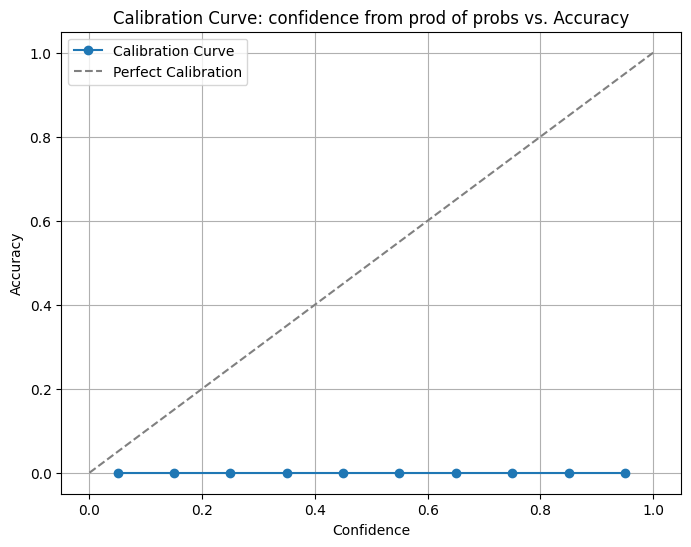

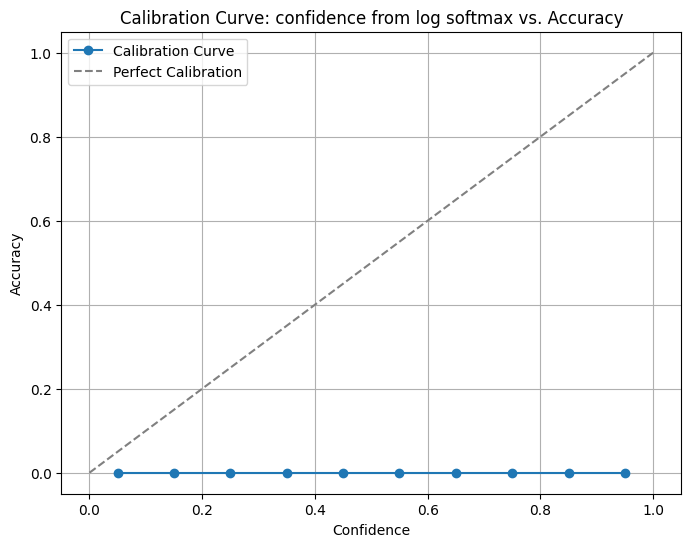

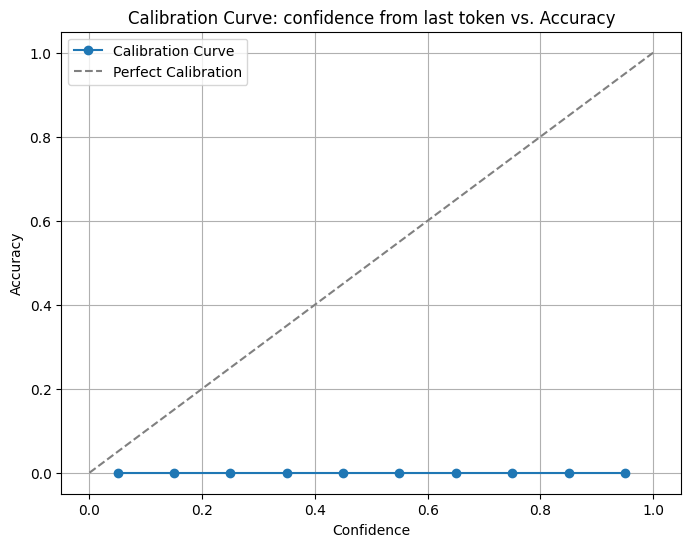

In [14]:
# Plot calibration curves
plot_calibration_curve(entropy_sequence_probs, accuracies, 'prod of probs', num_bins=10)
plot_calibration_curve(entropy_log_softmax, accuracies, 'log softmax', num_bins=10)
plot_calibration_curve(entropy_last_token_probs, accuracies, 'last token', num_bins=10)

In [41]:
def normalize_data(data):
    """Normalize data to the range [0, 1]."""
    min_val = np.min(data)
    max_val = np.max(data)
    if max_val > min_val:
        return (data - min_val) / (max_val - min_val)
    else:
        return np.zeros_like(data)  # Avoid division by zero if all values are the same

In [42]:
normalized_entropy_sequence_probs = normalize_data(entropy_sequence_probs)
normalized_entropy_log_softmax = normalize_data(entropy_log_softmax)
normalized_entropy_last_token_probs = normalize_data(entropy_last_token_probs)


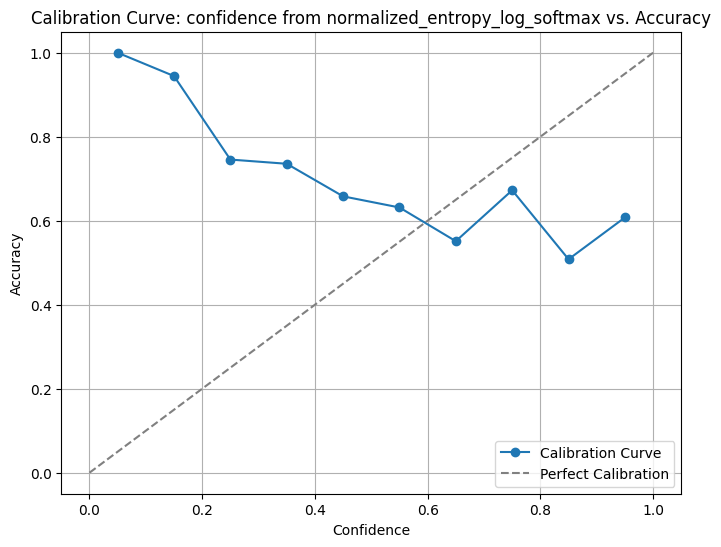

In [48]:
# Plot calibration curves
# plot_calibration_curve(normalized_entropy_sequence_probs, accuracies, num_bins=10)
plot_calibration_curve(normalized_entropy_log_softmax, accuracies, 'normalized_entropy_log_softmax', num_bins=10)
# plot_calibration_curve(normalized_entropy_last_token_probs, accuracies, 'normalized_entropy_log_softmax', num_bins=10)